<div style='text-align:center;'>
  <img src="Ensemble5.PNG" width="1200">
</div>

## **CardioPredict AI - Heart Disease Clinical Decision Support Dashboard**

In [2]:
# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import json
import os
import shap

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, roc_curve)
import xgboost as xgb

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [3]:
# %% [markdown]
# ## 1. Data Importation & Exploration

# %%
print("🔄 Loading dataset...")
df = pd.read_csv('Heart.csv', na_values=['NA', '?', ''])

# Map target variable
df['AHD'] = df['AHD'].map({'No': 0, 'Yes': 1})

# Drop target and any irrelevant ID columns
cols_to_drop = [c for c in ['AHD', 'hd'] if c in df.columns]
X = df.drop(columns=cols_to_drop)
y = df['AHD']

# Define feature types
num_features = ['Age', 'RestBP', 'Chol', 'MaxHR', 'Oldpeak', 'Ca']
cat_features = ['Sex', 'ChestPain', 'Fbs', 'RestECG', 'ExAng', 'Slope', 'Thal']
feature_names = num_features + cat_features

print(f"✅ Dataset loaded successfully. Shape: {df.shape}")
display(df.head())


🔄 Loading dataset...
✅ Dataset loaded successfully. Shape: (303, 15)


,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD,HD
0,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,0,0
1,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,1,1
2,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,1,1
3,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,0,0
4,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,0,0


In [4]:
# %% [markdown]
# ## 2. Preprocessing & Train/Test Split

# %%
# Numeric pipeline: Impute missing with median, then scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline: Impute missing with most frequent, then ordinal encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

# Combine into a single preprocessor
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_features),
    ('cat', categorical_transformer, cat_features)
], remainder='drop')

# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42)

# Calculate class weight for XGBoost to handle imbalance
pos_weight_train = (y_train == 0).sum() / (y_train == 1).sum()
print(f"✅ Preprocessing configured. Train size: {len(X_train)}, Test size: {len(X_test)}")

✅ Preprocessing configured. Train size: 242, Test size: 61


In [5]:
# %% [markdown]
# ## 3. Model Definitions & Hyperparameter Tuning

# %%
SEED = 42
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

model_configs = {
    "Random Forest": {
        "pipeline": Pipeline([
            ("preprocessor", preprocessor),
            ("model", RandomForestClassifier(random_state=SEED, n_jobs=-1, class_weight='balanced'))
        ]),
        "params": {
            "model__n_estimators": [100, 200, 300],
            "model__max_depth": [None, 10, 15],
            "model__min_samples_split": [2, 5]
        },
    },
    "XGBoost": {
        "pipeline": Pipeline([
            ("preprocessor", preprocessor),
            ("model", xgb.XGBClassifier(random_state=SEED, eval_metric='logloss', n_jobs=-1, scale_pos_weight=pos_weight_train))
        ]),
        "params": {
            "model__n_estimators": [100, 200, 300],
            "model__max_depth": [3, 4, 5],
            "model__learning_rate": [0.05, 0.1, 0.2]
        },
    },
    "Logistic Regression": {
        "pipeline": Pipeline([
            ("preprocessor", preprocessor),
            ("model", LogisticRegression(max_iter=500, random_state=SEED))
        ]),
        "params": {"model__C": [0.01, 0.1, 1, 10, 100]},
    },
    "KNN": {
        "pipeline": Pipeline([
            ("preprocessor", preprocessor),
            ("model", KNeighborsClassifier())
        ]),
        "params": {"model__n_neighbors": [3, 5, 7, 9, 11]},
    },
    "SVM": {
        "pipeline": Pipeline([
            ("preprocessor", preprocessor),
            ("model", SVC(probability=True, random_state=SEED))
        ]),
        "params": {"model__C": [0.1, 1, 10], "model__kernel": ["linear", "rbf"]},
    },
}

In [6]:
# %% [markdown]
# ## 4. Training Loop
# *Note: This cell may take a few minutes to run as it performs GridSearchCV for 5 models.*

# %%
metrics_all = {}
roc_data = {}
trained_models = {}

for name, cfg in model_configs.items():
    print(f"\n🚀 Training {name}...")
    grid = GridSearchCV(cfg["pipeline"], cfg["params"], cv=cv, scoring="roc_auc", n_jobs=-1)
    grid.fit(X_train, y_train)
    
    best = grid.best_estimator_
    trained_models[name] = best
    print(f"  ✅ Best params: {grid.best_params_}")

    # Predictions
    pred = best.predict(X_test)
    prob = best.predict_proba(X_test)[:, 1]

    # Metrics
    metrics_all[name] = {
        "Accuracy":  round(accuracy_score(y_test, pred), 4),
        "Precision": round(precision_score(y_test, pred), 4),
        "Recall":    round(recall_score(y_test, pred), 4),
        "F1 Score":  round(f1_score(y_test, pred), 4),
        "ROC-AUC":   round(roc_auc_score(y_test, prob), 4),
        "confusion_matrix": confusion_matrix(y_test, pred).tolist()
    }

    # ROC Data
    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_data[name] = {"fpr": fpr.tolist(), "tpr": tpr.tolist(), "auc": metrics_all[name]["ROC-AUC"]}

print("\n✅ All models trained successfully!")


🚀 Training Random Forest...
  ✅ Best params: {'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 200}

🚀 Training XGBoost...
  ✅ Best params: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100}

🚀 Training Logistic Regression...
  ✅ Best params: {'model__C': 1}

🚀 Training KNN...
  ✅ Best params: {'model__n_neighbors': 11}

🚀 Training SVM...
  ✅ Best params: {'model__C': 0.1, 'model__kernel': 'linear'}

✅ All models trained successfully!


In [7]:
# %% [markdown]
# ## 5. Model Evaluation

# %%
# 5.1 Metrics Table
metrics_df = pd.DataFrame(metrics_all).T[['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']]
display(metrics_df.style.highlight_max(axis=0, color='lightgreen'))

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Random Forest,0.918000,0.871000,0.964300,0.915300,0.960000
XGBoost,0.901600,0.843800,0.964300,0.900000,0.947000
Logistic Regression,0.901600,0.866700,0.928600,0.896600,0.953500
KNN,0.868900,0.857100,0.857100,0.857100,0.948600
SVM,0.885200,0.862100,0.892900,0.877200,0.955600


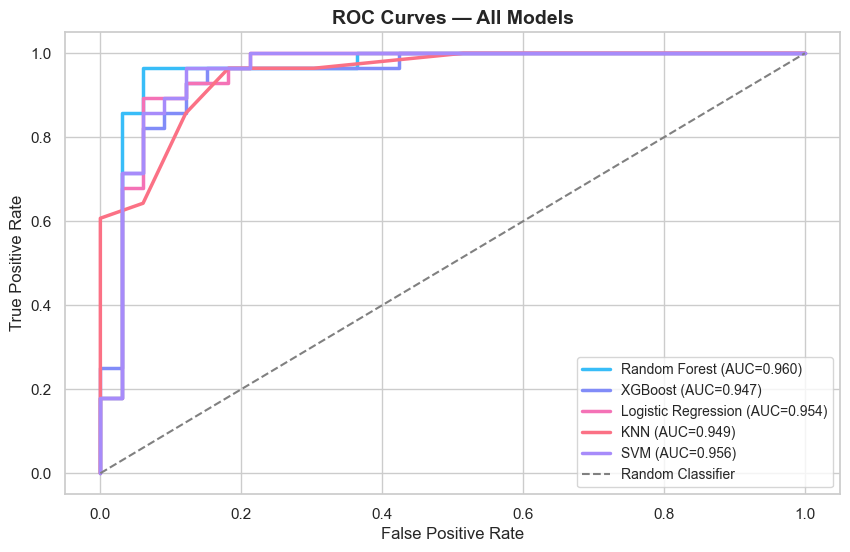

In [8]:
# %%
# 5.2 ROC Curves
plt.figure(figsize=(10, 6))
palette = ["#38bdf8", "#818cf8", "#f472b6", "#fb7185", "#a78bfa"]
for (name, rd), color in zip(roc_data.items(), palette):
    plt.plot(rd["fpr"], rd["tpr"], lw=2.5, color=color, label=f"{name} (AUC={rd['auc']:.3f})")
    
plt.plot([0,1],[0,1],"--", color="gray", lw=1.5, label="Random Classifier")
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curves — All Models", fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.show()

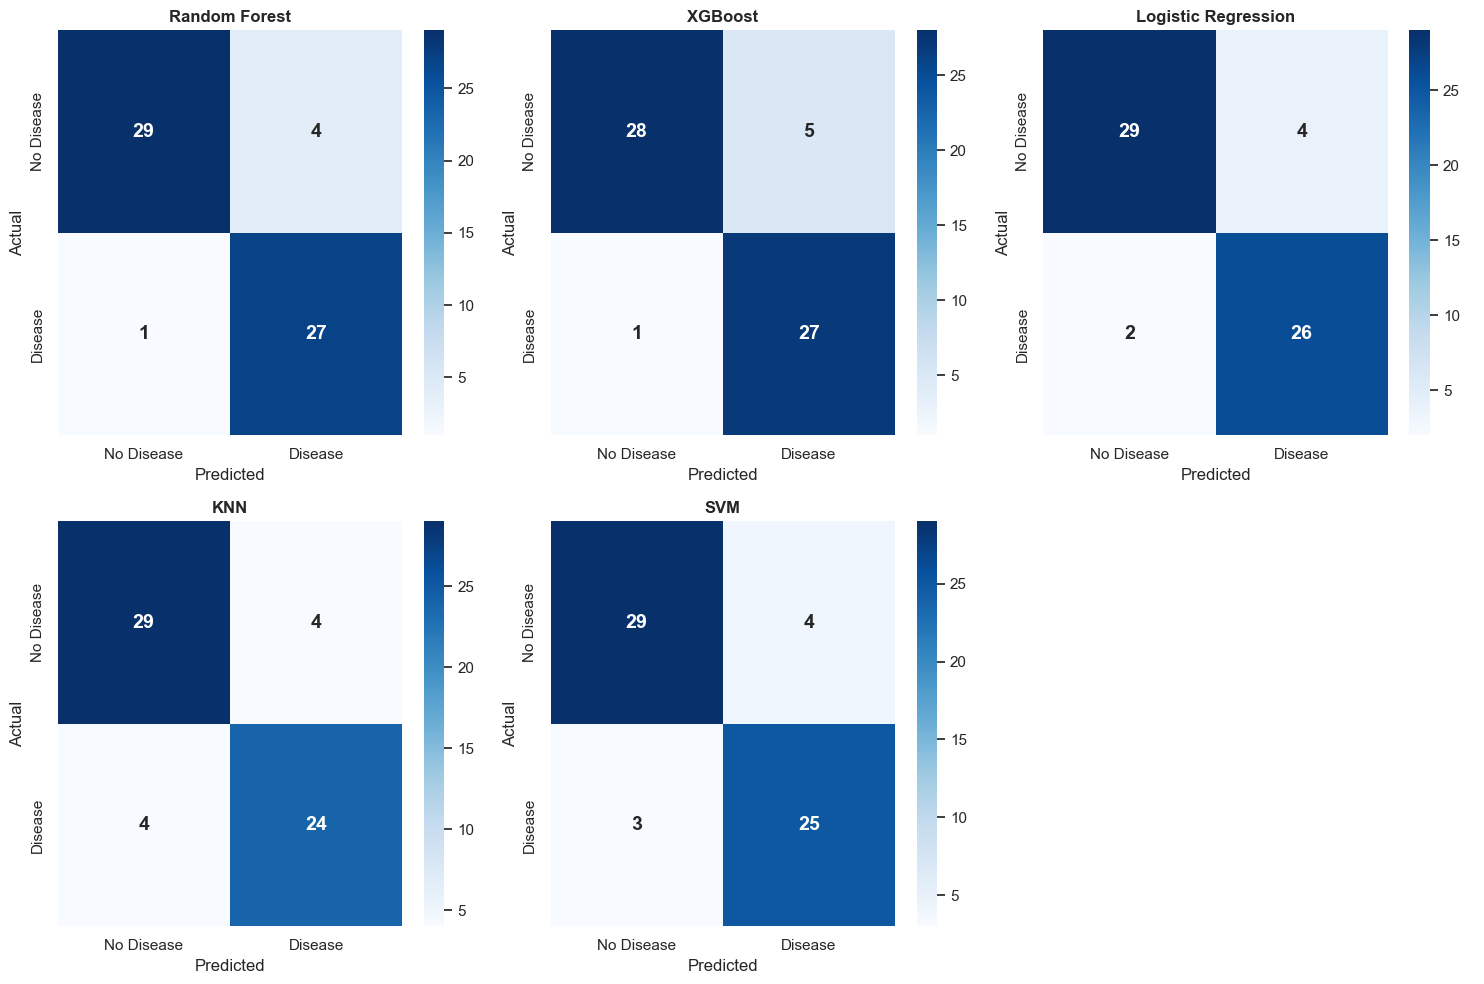

In [9]:
# %%
# 5.3 Confusion Matrices
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, (name, m) in enumerate(metrics_all.items()):
    cm = np.array(m["confusion_matrix"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[i],
                xticklabels=["No Disease","Disease"], yticklabels=["No Disease","Disease"],
                annot_kws={"size": 14, "weight": "bold"})
    axes[i].set_title(name, fontsize=12, fontweight='bold')
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

# Hide the last empty subplot if there are only 5 models
if len(metrics_all) < 6:
    axes[-1].axis('off')

plt.tight_layout()
plt.show()


🧠 Computing SHAP for Random Forest...


<Figure size 1000x600 with 0 Axes>

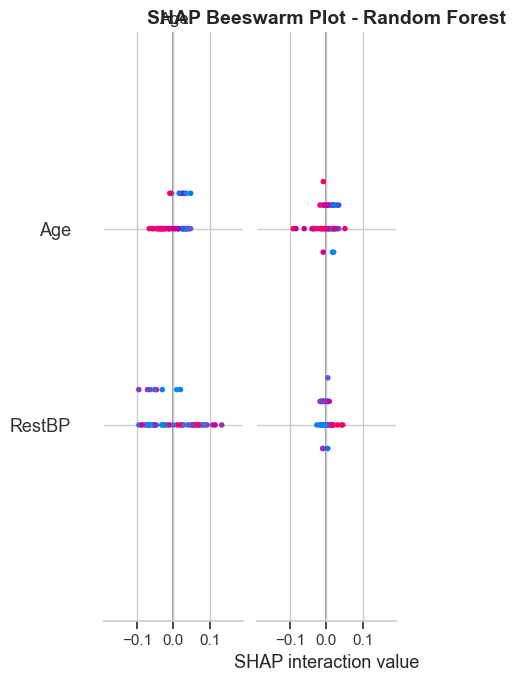


🧠 Computing SHAP for XGBoost...


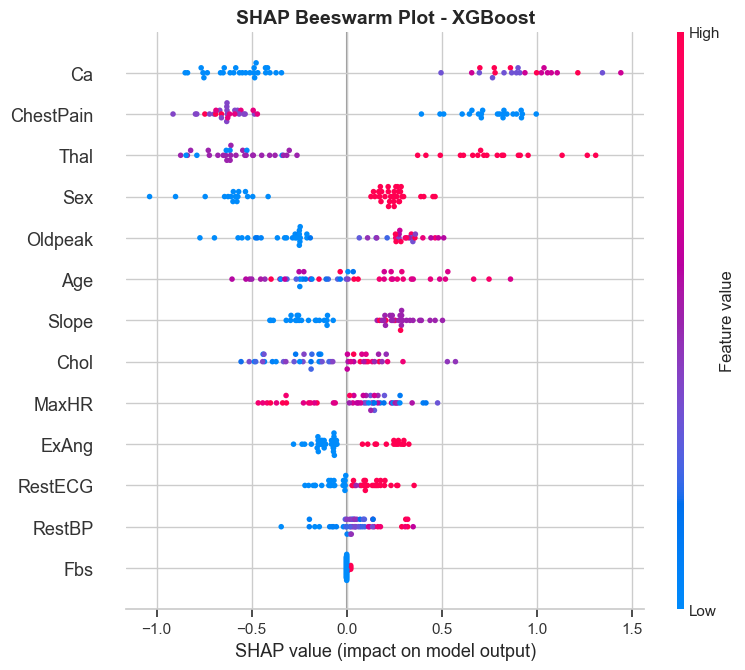


🧠 Computing SHAP for Logistic Regression...


  0%|          | 0/50 [00:00<?, ?it/s]

<Figure size 1000x600 with 0 Axes>

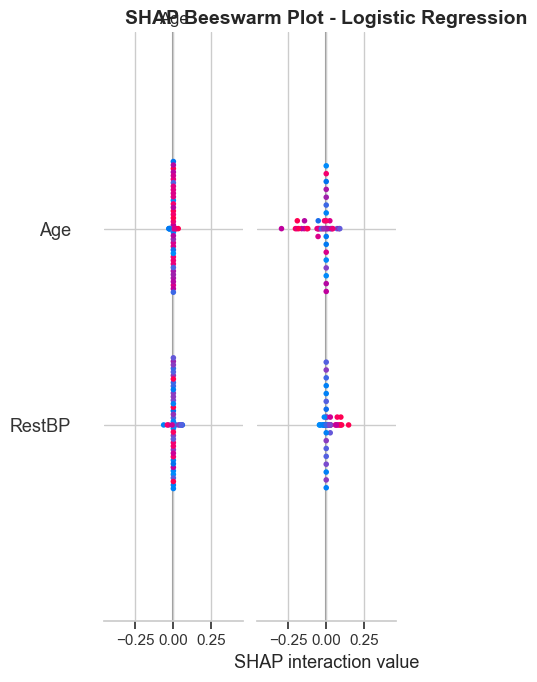


🧠 Computing SHAP for KNN...


  0%|          | 0/50 [00:00<?, ?it/s]

<Figure size 1000x600 with 0 Axes>

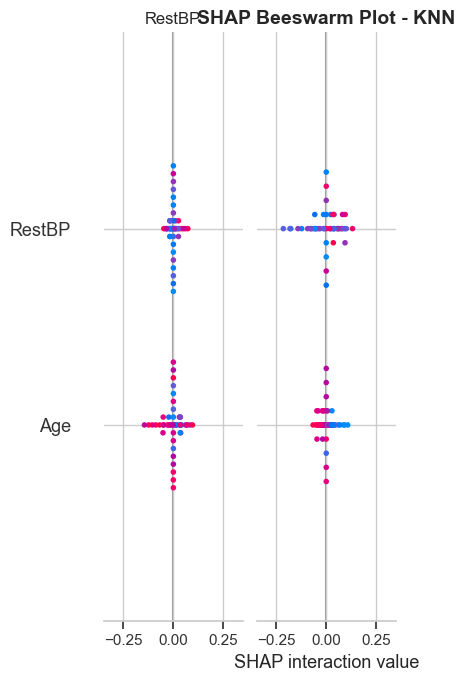


🧠 Computing SHAP for SVM...


  0%|          | 0/50 [00:00<?, ?it/s]

<Figure size 1000x600 with 0 Axes>

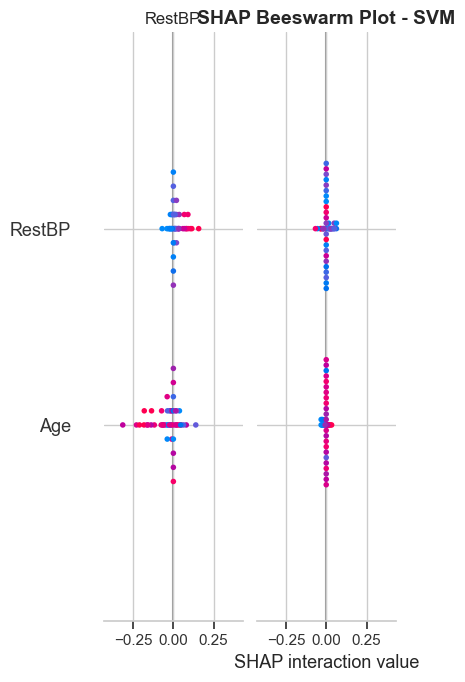

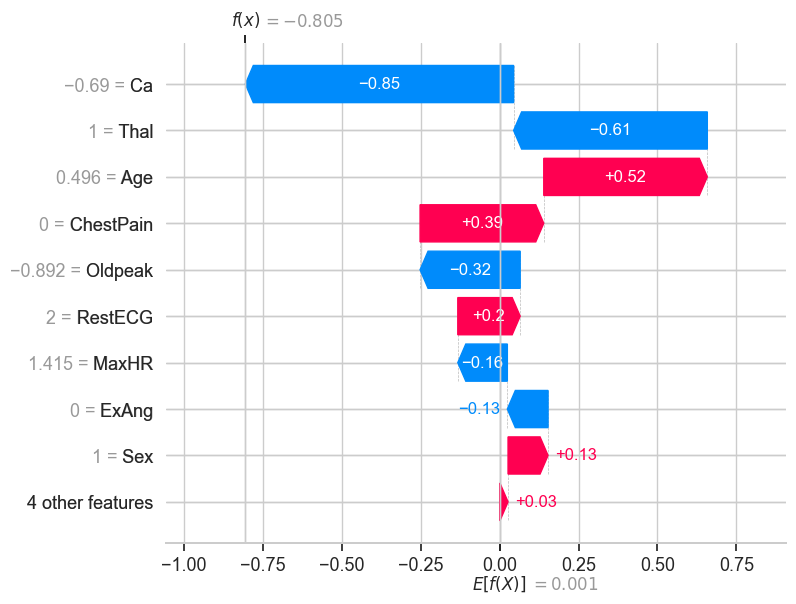

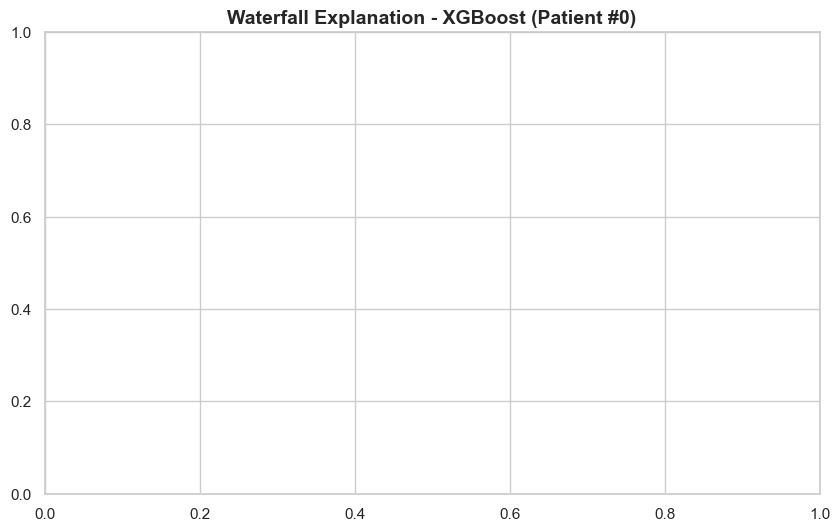

In [17]:
# %% [markdown]
# ## 6. Explainable AI (SHAP Analysis)

# %%
# 6.1 Tree-Based Models (Random Forest, XGBoost)
tree_models = ["Random Forest", "XGBoost"]
for name in tree_models:
    print(f"\n🧠 Computing SHAP for {name}...")
    model = trained_models[name]
    
    # Extract the underlying model from the pipeline
    base_model = model.named_steps['model']
    explainer = shap.TreeExplainer(base_model)
    
    # Transform a sample of the test data
    X_test_sample = X_test[:50]
    X_test_trans = model.named_steps['preprocessor'].transform(X_test_sample)
    shap_values = explainer.shap_values(X_test_trans)
    
    # Handle binary classification output
    if isinstance(shap_values, list):
        sv_pos = shap_values[1]
    else:
        sv_pos = shap_values
        
    plt.figure()
    # FIX: Pass the TRANSFORMED data (X_test_trans) to the plot, not the raw data
    shap.summary_plot(sv_pos, X_test_trans, feature_names=feature_names, plot_type="dot", show=False)
    plt.title(f"SHAP Beeswarm Plot - {name}", fontsize=14, fontweight='bold')
    plt.show()

# %%
# 6.2 Non-Tree Models (Logistic Regression, KNN, SVM)
non_tree_models = ["Logistic Regression", "KNN", "SVM"]
for name in non_tree_models:
    print(f"\n🧠 Computing SHAP for {name}...")
    model = trained_models[name]
    
    # Transform data
    X_train_trans = model.named_steps['preprocessor'].transform(X_train)
    X_test_sample = X_test[:50]
    X_test_trans = model.named_steps['preprocessor'].transform(X_test_sample)
    
    # Use KernelExplainer with a background dataset
    background = shap.sample(X_train_trans, 50, random_state=42)
    base_model = model.named_steps['model']
    explainer = shap.KernelExplainer(base_model.predict_proba, background)
    
    shap_values = explainer.shap_values(X_test_trans, nsamples=100)
    
    if isinstance(shap_values, list):
        sv_pos = shap_values[1]
    else:
        sv_pos = shap_values
        
    plt.figure()
    # FIX: Pass the TRANSFORMED data (X_test_trans) to the plot
    shap.summary_plot(sv_pos, X_test_trans, feature_names=feature_names, plot_type="dot", show=False)
    plt.title(f"SHAP Beeswarm Plot - {name}", fontsize=14, fontweight='bold')
    plt.show()

# %%
# 6.3 Individual Waterfall Plot (Example: XGBoost)
name = "XGBoost"
model = trained_models[name]
base_model = model.named_steps['model']
explainer = shap.TreeExplainer(base_model)

# Get single patient data
X_test_sample = X_test[:1]
X_test_trans = model.named_steps['preprocessor'].transform(X_test_sample)
shap_values = explainer.shap_values(X_test_trans)

if isinstance(shap_values, list):
    sv_pos = shap_values[1]
else:
    sv_pos = shap_values

ev = explainer.expected_value
if hasattr(ev, '__len__'): 
    ev = ev[1]

# Create Explanation object for the waterfall plot
exp = shap.Explanation(
    values=sv_pos[0],
    base_values=float(ev),
    data=X_test_trans[0], # Use transformed data
    feature_names=feature_names
)

plt.figure()
shap.plots.waterfall(exp, max_display=10, show=True)
plt.title(f"Waterfall Explanation - {name} (Patient #0)", fontsize=14, fontweight='bold')
plt.show()

In [18]:
# %% [markdown]
# ## 7. Save Artifacts for Streamlit Deployment

# %%
os.makedirs("models", exist_ok=True)

# Save data and preprocessor
joblib.dump(feature_names, "models/feature_names.pkl")
joblib.dump((X_test, y_test), "models/test_data.pkl")
joblib.dump(preprocessor, "models/preprocessor.pkl")

# Save trained models
for name, model in trained_models.items():
    safe_name = name.lower().replace(" ", "_")
    joblib.dump(model, f"models/{safe_name}.pkl")

# Save metrics and ROC data
with open("models/metrics.json", "w") as f:
    json.dump(metrics_all, f, indent=2)
with open("models/roc_data.json", "w") as f:
    json.dump(roc_data, f, indent=2)

print("\n✅ All models, metrics, and artifacts saved to the ./models/ directory.")
print("🚀 You can now run your Streamlit app: `streamlit run app.py`")


✅ All models, metrics, and artifacts saved to the ./models/ directory.
🚀 You can now run your Streamlit app: `streamlit run app.py`
